###Ejercicio 1):
 Utilice lo aprendido en los trabajos prácticos previos (uso de biopython para obtenersecuencias, BLAST y el “parser del mismo”) para:

 i) obtener 10 secuencias pertenecientes a una misma familia y

 ii) Alinearlas y obtener la correspondiente matriz de puntaje / identidad

 Analice si la matriz es (o no) simetrica

 Compare matrices utilizando diferentes puntajes que le otorga BLAST (Bit Score, Identidad, E-Value)

Lista de 10 proteinas CYP1A1 de distintas especies

In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 34.0 MB/s eta 0:00:00


In [ ]:
from Bio import SeqIO, pairwise2
from Bio.Align import substitution_matrices
import numpy as np
import pandas as pd
import copy
from Bio import Phylo
from io import StringIO


/usr/local/lib/python3.12/dist-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [ ]:
!wget ftp://ftp.ncbi.nlm.nih.gov/blast/executables/blast+/LATEST/ncbi-blast-*-x64-linux.tar.gz
!tar -xzf ncbi-blast-*-x64-linux.tar.gz
!mv ncbi-blast-*/bin/* /usr/local/bin/

--2025-09-26 14:37:16--  ftp://ftp.ncbi.nlm.nih.gov/blast/executables/blast+/LATEST/ncbi-blast-*-x64-linux.tar.gz
           => ‘.listing’
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.11, 130.14.250.12, 130.14.250.13, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.11|:21... connected.
Logging in as anonymous ... Logged in!
==> SYST ... done.    ==> PWD ... done.
==> TYPE I ... done.  ==> CWD (1) /blast/executables/blast+/LATEST ... done.
==> PASV ... done.    ==> LIST ... done.

.listing                [ <=>                ]   2.62K  --.-KB/s    in 0.003s  

2025-09-26 14:37:16 (786 KB/s) - ‘.listing’ saved [2678]

Removed ‘.listing’.
--2025-09-26 14:37:16--  ftp://ftp.ncbi.nlm.nih.gov/blast/executables/blast%2B/LATEST/ncbi-blast-2.17.0%2B-x64-linux.tar.gz
           => ‘ncbi-blast-2.17.0+-x64-linux.tar.gz’
==> CWD not required.
==> PASV ... done.    ==> RETR ncbi-blast-2.17.0+-x64-linux.tar.gz ... done.
Length: 296006458 (282M)

ncbi-bl

In [ ]:
import pandas as pd
def cargar_blosum60(path="blosum60.txt"):
    with open(path) as f:
        lines = [line.strip() for line in f if not line.startswith("#")]

    header = lines[0].split()
    data = []
    index = []

    for line in lines[1:]:
        parts = line.split()
        index.append(parts[0])
        data.append([int(x) for x in parts[1:]])

    df = pd.DataFrame(data, index=index, columns=header)
    return df

# Cargar matriz
blosum60_df = cargar_blosum60()

# Mostrar parte de la matriz

def df_to_blosum_dict(df):
    matrix = {}
    for i in df.index:
        for j in df.columns:
            score = df.at[i, j]
            matrix[(i, j)] = score
            matrix[(j, i)] = score  # aseguramos simetría
    return matrix


blosum_dict = df_to_blosum_dict(blosum60_df)


**def blast_two_seqs**

    """
    Hace BLASTp local entre dos secuencias proteicas y devuelve métricas clave.

    Args:
      seq_query (str): Secuencia proteica que será la consulta.
      seq_db (str): Secuencia proteica que será la base de datos.
      id_query (str): ID para la secuencia consulta.
      id_db (str): ID para la secuencia base de datos.
      temp_dir (str): Carpeta temporal para archivos.

    Returns:
      tuple: (evalue, bitscore, pident) del mejor hit.
             Si no hay hits, devuelve (None, None, None).
    """

In [ ]:
import os

def blast_two_seqs(seq_query, seq_db, id_query="query", id_db="db", temp_dir="temp_blast"):
    if not os.path.exists(temp_dir):
        os.makedirs(temp_dir)

    # Crear archivo fasta para consulta
    query_path = os.path.join(temp_dir, "query.fasta")
    with open(query_path, "w") as f:
        f.write(f">{id_query}\n{seq_query}\n")

    # Crear archivo fasta para base de datos
    db_path = os.path.join(temp_dir, "db.fasta")
    with open(db_path, "w") as f:
        f.write(f">{id_db}\n{seq_db}\n")

    # Crear base de datos local
    db_name = os.path.join(temp_dir, "db")
    cmd_make_db = f"makeblastdb -in {db_path} -dbtype prot -out {db_name} -logfile /dev/null"
    os.system(cmd_make_db)

    # Ejecutar blastp
    output_path = os.path.join(temp_dir, "blast_out.txt")
    cmd_blast = (
        f"blastp -query {query_path} -db {db_name} "
        f"-out {output_path} -outfmt '6 evalue bitscore pident' "
        f"-max_target_seqs 1 -num_threads 1"
    )
    os.system(cmd_blast)

    # Leer resultado
    evalue, bitscore, pident = None, None, None
    if os.path.exists(output_path):
        with open(output_path) as f:
            line = f.readline().strip()
            if line:
                evalue_str, bitscore_str, pident_str = line.split("\t")
                evalue = float(evalue_str)
                bitscore = float(bitscore_str)
                pident = float(pident_str)

    return evalue, bitscore, pident


#Obtenemos 10 secuencias de la familia quinasa

In [ ]:

from Bio import Entrez, SeqIO

Entrez.email = "joaquinsalva03@gmail.com"

# Paso 1: buscar proteínas asociadas a una familia en NCBI Protein
# Ejemplo: globinas
handle = Entrez.esearch(
    db="protein",
    term="Protein kinase[Protein Name]",
    retmax=10  # cantidad de secuencias a traer
)
record = Entrez.read(handle)
handle.close()
lista_quinasas_id = record["IdList"]
print(lista_quinasas_id)

print("IDs encontrados:", record["IdList"])

# Paso 2: bajar las secuencias en formato fasta
handle = Entrez.efetch(
    db="protein",
    id=",".join(record["IdList"]),
    rettype="fasta",
    retmode="text"
)

# Paso 3: parsear a strings y guardarlas en una lista
lista_quinasas = [str(rec.seq) for rec in SeqIO.parse(handle, "fasta")]
handle.close()

print("Número de secuencias:", len(lista_quinasas))



['3064162935', '3064158066', '3063888818', '3063884927', '3063834559', '3063804125', '2924247891', '2575255726', '2573173597', '2511548032']
IDs encontrados: ['3064162935', '3064158066', '3063888818', '3063884927', '3063834559', '3063804125', '2924247891', '2575255726', '2573173597', '2511548032']
Número de secuencias: 10


In [ ]:
def guardar_lista_fasta(lista_secuencias, output_path="secuencias.fasta", prefix="Prot_"):
    with open(output_path, "w") as f:
        for i, seq in enumerate(lista_secuencias):
            f.write(f">{prefix}{i}\n")
            f.write(f"{seq}\n")
guardar_lista_fasta(lista_quinasas, "quinasas.fasta")


In [ ]:
# Cargar matriz
blosum60_df = cargar_blosum60()
def obtener_matriz_blast_scores(lista_proteinas):
    # Inicializar matriz
    n = len(lista_proteinas)
    evalue_matrix, bitscore_matrix, pident_matrix = np.zeros((n, n)), np.zeros((n, n)),np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            seq1 = lista_proteinas[i]
            seq2 = lista_proteinas[j]
            evalue, bitscore, pident = blast_two_seqs(seq1, seq2)
            evalue_matrix[i][j]= evalue
            bitscore_matrix[i][j] = bitscore
            pident_matrix[i][j]  =  pident


    maximo = np.nanmax(evalue_matrix)
    evalue_matrix = np.nan_to_num(evalue_matrix, nan=maximo)

    bitscore_matrix = np.nan_to_num(bitscore_matrix, nan=0)

    pident_matrix = np.nan_to_num(pident_matrix, nan=0)
    return evalue_matrix, bitscore_matrix, pident_matrix

Ejercicio 2): Programe un algoritmo que dada una matriz de distancias construya un árbol guía.Utilice el mismo para trabajar con las diferentes matrices obtenidas a partir de los puntajes deBLAST y analice los resultados de manera comparativa.

# De la matriz al arbol guia

## De la matriz al arbol

Tomamos la matriz de distancias y, reduciendo su dimension, calculamos el agrupamiento de nodos del arbol guia

Para esto tenemos que:

* Tener una matriz de distancias donde las columnas y las filas son un conjunto de secuencias (que lo llamamos C).
* encontrar el maximo valor de la matriz
  junto con sus coordenadas
  maximo = distancia (A,B), con A,B en C, y su distancia el maximo score, es decir, mayor parecido entre si.  
* Quito las filas y columnas donde se vea distancias de A o B a otra secuencia X
* Armo una fila que sea distancia ((AB, X)

De esta manera, evitamos recalcular toda la matriz de distancia, donde lo que nos interesa modificar es aquellas filas, columnas que se vean afectadas

## Graficar el arbol guia

Encontrar minimo y maximo nos permiten personalizar la matriz que hace el arbol guia segun si queremos hacerlo por e-value o pident.

Actualizar matriz reduce la dimension de la matriz, actualizadola al alineamiento multiple que se tomo de acuerdo al minimo o maximo.


In [ ]:
import numpy as np

def imprimir_matriz(matriz, etiquetas):
    print("\nMatriz actual:")
    df = pd.DataFrame(matriz, index=etiquetas, columns=etiquetas)
    display(df)
    return

def encontrar_maximo(matriz):
    n = len(matriz)
    max_val = float('-inf')  # empezamos desde -infinito
    coords = (-1, -1)
    for i in range(n):
        for j in range(i+1, n):  # triángulo superior
            if matriz[i][j] > max_val:
                max_val = matriz[i][j]
                coords = (i, j)
    return coords, max_val

def encontrar_minimo(matriz):
    n = len(matriz)
    min_val = float('inf')  # empezamos desde infinito
    coords = (-1, -1)
    for i in range(n):
        for j in range(i+1, n):  # triángulo superior
            if matriz[i][j] < min_val:
                min_val = matriz[i][j]
                coords = (i, j)
    return coords, min_val


def calcular_distancia_promedio(matriz, i, j):
    n = len(matriz)
    nueva_fila = []
    for k in range(n):
        if k != i and k != j:
            d = (matriz[i][k] + matriz[j][k]) / 2
            nueva_fila.append(d)
    return nueva_fila

def actualizar_matriz(matriz, etiquetas, i, j):
    # Unimos etiquetas como una string (sin espacios si lo querés tipo Newick)
    nueva_etiqueta = f"({etiquetas[i]},{etiquetas[j]})"

    nueva_fila = calcular_distancia_promedio(matriz, i, j)

    # Eliminar i y j (mayor índice primero)
    indices = sorted([i, j], reverse=True)
    for idx in indices:
        matriz = np.delete(matriz, idx, axis=0)
        matriz = np.delete(matriz, idx, axis=1)
        etiquetas.pop(idx)

    # Agregar nueva fila/columna
    matriz = np.vstack([matriz, nueva_fila])
    nueva_col = nueva_fila + [0.0]
    matriz = np.column_stack([matriz, nueva_col])
    etiquetas.append(nueva_etiqueta)

    return matriz, etiquetas


   ### armar_arbol_guia

    """
    Genera arbol en formato newick

    Args:
        matriz: matriz de puntajes de alineamientos todas con todas.
        etiquetas: Forma de identificar a cada secuencia que aparecera en el arbol
        tipo_score: Cual fue el criterio de agrupamiento (minimo e-value, maximo pident)
    """

In [ ]:
def armar_arbol_guia(matriz, etiquetas, tipo_score):
      paso = 1
      while len(etiquetas) > 1:
          imprimir_matriz(matriz, etiquetas)
          if tipo_score in ['bitscore', 'pident']:
              (i, j), max_val = encontrar_maximo(matriz)
              print(f"\nPaso {paso}: Agrupando '{etiquetas[i]}' y '{etiquetas[j]}' con {tipo_score} maximo {max_val}")

          if tipo_score == 'evalue':
              (i, j), min_val = encontrar_minimo(matriz)
              print(f"\nPaso {paso}: Agrupando '{etiquetas[i]}' y '{etiquetas[j]}' con evalue mínimo {min_val}")

          matriz, etiquetas = actualizar_matriz(matriz, etiquetas, i, j)
          paso += 1

      print("\nÁrbol final:", etiquetas[0])
      return etiquetas[0]


Miramos los distintos arboles guias que se generan de acuerdo a si los armamos por bitscore, pident o e-value

In [ ]:

evalue_matrix, bitscore_matrix, pident_matrix = obtener_matriz_blast_scores(lista_quinasas)
print(evalue_matrix)
print(bitscore_matrix)
print(pident_matrix)

labels = [ f"Prot {i}" for i in range(len(lista_quinasas))]
arbol_bitscore = armar_arbol_guia(bitscore_matrix, labels, 'bitscore')
labels = [ f"Prot {i}" for i in range(len(lista_quinasas))]
arbol_pident = armar_arbol_guia(pident_matrix, labels, 'pident')
labels = [ f"Prot {i}" for i in range(len(lista_quinasas))]
arbol_evalue = armar_arbol_guia(evalue_matrix, labels, 'evalue')

tree_bitscore = Phylo.read(StringIO(arbol_bitscore), "newick")
tree_pident = Phylo.read(StringIO(arbol_pident), "newick")
tree_evalue = Phylo.read(StringIO(arbol_evalue), "newick")

[[5.85e-123 1.20e+000 6.10e+000 1.10e+000 2.40e-001 7.10e-002 2.40e+000
  9.20e+000 9.20e+000 3.30e+000]
 [1.30e+000 0.00e+000 6.90e-001 1.10e-001 3.10e-001 6.30e+000 1.70e+000
  1.60e+000 1.80e+000 1.70e+000]
 [6.10e+000 7.20e-001 0.00e+000 1.31e-019 2.56e-006 1.10e+000 5.50e-005
  2.50e-001 2.40e-001 5.00e-003]
 [1.10e+000 4.30e-001 1.65e-019 0.00e+000 2.00e-002 5.30e-001 3.50e-002
  5.00e-003 4.00e-003 1.60e+000]
 [2.40e-001 4.20e+000 2.56e-006 2.10e-002 0.00e+000 3.30e+000 8.91e-155
  3.80e+000 9.20e-001 3.20e-001]
 [7.10e-002 6.30e+000 1.10e+000 5.00e-001 3.30e+000 0.00e+000 2.40e-001
  6.70e+000 4.70e-001 9.20e-001]
 [2.40e+000 1.80e+000 5.50e-005 3.40e-002 8.91e-155 2.40e-001 0.00e+000
  5.50e-001 5.60e-001 2.60e-001]
 [9.20e+000 2.00e+000 2.20e-001 5.00e-003 3.20e+000 5.80e+000 6.40e-001
  2.45e-147 8.46e-146 9.20e+000]
 [9.20e+000 2.20e+000 2.10e-001 3.00e-003 8.20e-001 4.00e-001 6.60e-001
  8.46e-146 3.47e-148 9.20e+000]
 [3.80e+000 8.50e-001 5.00e-003 1.10e+000 3.90e-001 7.8

,Prot 0,Prot 1,Prot 2,Prot 3,Prot 4,Prot 5,Prot 6,Prot 7,Prot 8,Prot 9
Prot 0,330.0,15.8,13.5,16.2,17.7,19.2,14.6,0.0,0.0,15.4
Prot 1,15.8,1030.0,18.1,21.6,19.2,15.0,16.9,15.8,15.8,18.1
Prot 2,13.5,18.1,915.0,78.2,35.4,17.3,31.2,18.1,18.1,25.8
Prot 3,16.2,19.2,77.8,1385.0,23.5,18.9,22.7,23.9,24.3,18.5
Prot 4,17.7,15.8,35.4,23.5,893.0,15.8,434.0,14.2,16.2,20.0
Prot 5,19.2,15.0,17.3,18.9,15.8,891.0,19.2,13.5,16.9,18.5
Prot 6,14.6,16.9,31.2,22.7,434.0,19.2,915.0,16.9,16.9,20.4
Prot 7,0.0,15.4,18.1,23.9,14.6,13.9,16.9,395.0,391.0,14.2
Prot 8,0.0,15.4,18.1,24.6,16.5,17.3,16.5,391.0,397.0,0.0
Prot 9,15.0,18.9,25.8,18.9,19.6,21.9,20.4,15.0,18.9,1827.0



Paso 1: Agrupando 'Prot 4' y 'Prot 6' con bitscore maximo 434.0

Matriz actual:


,Prot 0,Prot 1,Prot 2,Prot 3,Prot 5,Prot 7,Prot 8,Prot 9,"(Prot 4,Prot 6)"
Prot 0,330.00,15.80,13.5,16.2,19.2,0.00,0.00,15.4,16.15
Prot 1,15.80,1030.00,18.1,21.6,15.0,15.80,15.80,18.1,16.35
Prot 2,13.50,18.10,915.0,78.2,17.3,18.10,18.10,25.8,33.30
Prot 3,16.20,19.20,77.8,1385.0,18.9,23.90,24.30,18.5,23.10
Prot 5,19.20,15.00,17.3,18.9,891.0,13.50,16.90,18.5,17.50
Prot 7,0.00,15.40,18.1,23.9,13.9,395.00,391.00,14.2,15.55
Prot 8,0.00,15.40,18.1,24.6,17.3,391.00,397.00,0.0,16.55
Prot 9,15.00,18.90,25.8,18.9,21.9,15.00,18.90,1827.0,20.20
"(Prot 4,Prot 6)",16.15,16.35,33.3,23.1,17.5,15.55,16.55,20.2,0.00



Paso 2: Agrupando 'Prot 7' y 'Prot 8' con bitscore maximo 391.0

Matriz actual:


...


Paso 7: Agrupando 'Prot 1' y '(Prot 9,((Prot 4,Prot 6),(Prot 2,Prot 3)))' con evalue mínimo 1.31875

Matriz actual:


,"(Prot 7,Prot 8)","(Prot 0,Prot 5)","(Prot 1,(Prot 9,((Prot 4,Prot 6),(Prot 2,Prot 3))))"
"(Prot 7,Prot 8)",0.000000,6.150000,3.545875
"(Prot 0,Prot 5)",6.150000,0.000000,2.871563
"(Prot 1,(Prot 9,((Prot 4,Prot 6),(Prot 2,Prot 3))))",3.545875,2.871563,0.000000



Paso 8: Agrupando '(Prot 0,Prot 5)' y '(Prot 1,(Prot 9,((Prot 4,Prot 6),(Prot 2,Prot 3))))' con evalue mínimo 2.8715625

Matriz actual:


,"(Prot 7,Prot 8)","((Prot 0,Prot 5),(Prot 1,(Prot 9,((Prot 4,Prot 6),(Prot 2,Prot 3)))))"
"(Prot 7,Prot 8)",0.000000,4.847937
"((Prot 0,Prot 5),(Prot 1,(Prot 9,((Prot 4,Prot 6),(Prot 2,Prot 3)))))",4.847937,0.000000



Paso 9: Agrupando '(Prot 7,Prot 8)' y '((Prot 0,Prot 5),(Prot 1,(Prot 9,((Prot 4,Prot 6),(Prot 2,Prot 3)))))' con evalue mínimo 4.8479375

Árbol final: ((Prot 7,Prot 8),((Prot 0,Prot 5),(Prot 1,(Prot 9,((Prot 4,Prot 6),(Prot 2,Prot 3))))))


## Arboles generados online por distintos modulos


### Muscle

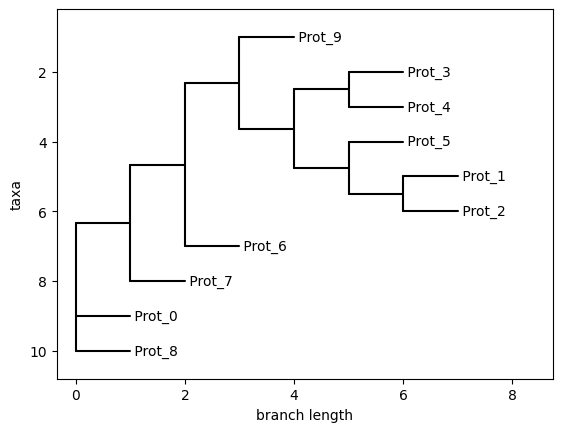

In [ ]:
#Muscle
tree = Phylo.read("arbol_muscle.phylotree", "newick")

tree_no_lengths = copy.deepcopy(tree)
for clade in tree_no_lengths.find_clades():
    clade.branch_length = None

Phylo.draw(tree_no_lengths)


### Clustalw

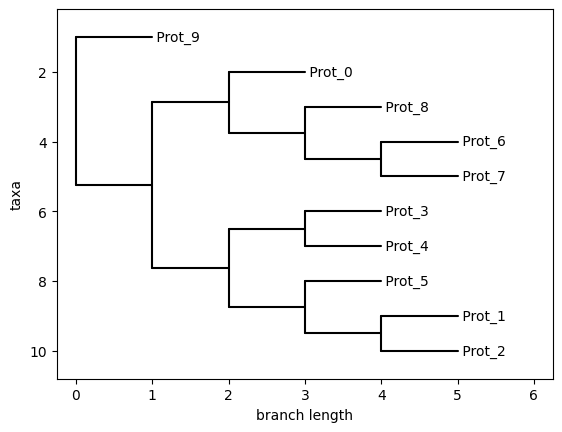

In [ ]:
tree = Phylo.read("arbol_clustalw.tree", "newick")

tree_no_lengths = copy.deepcopy(tree)
for clade in tree_no_lengths.find_clades():
    clade.branch_length = None

Phylo.draw(tree_no_lengths)


### Mafft

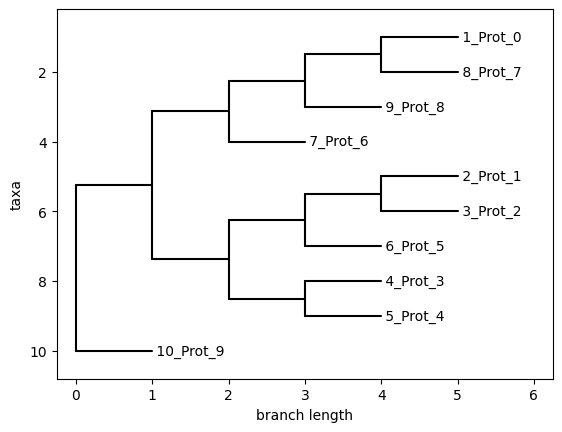

In [ ]:
tree = Phylo.read("arbol_mafft.tree", "newick")

tree_no_lengths = copy.deepcopy(tree)
for clade in tree_no_lengths.find_clades():
    clade.branch_length = None

Phylo.draw(tree_no_lengths)

# Punto 3. Armamos el alineamiento a partir del arbol guia

Procedimiento:
1. Bajamos en el arbol y contemplamos los casos de alinear...
    * **secuencia con secuencia**

            hacemos el alineamiento de a pares con pairwise2
    * **secuencia con alineamiento de pares**
    
            miramos scores cruzados y nos quedamos con el maximo. Usamos esa "version" de la secuencia como template para agregarlo al AM, poniendo los interlineados necesarios para mantener el score
2. Repetimos a medida que vamos subiendo en el arbol


In [ ]:
from Bio import pairwise2, Phylo
from io import StringIO
from Bio.Align import substitution_matrices

blosum62 = substitution_matrices.load("BLOSUM62")

def AP(seq1, seq2):
    alignments = pairwise2.align.globalds(seq1, seq2, blosum62, -10, -0.5)
    best_aln = max(alignments, key=lambda x: x.score)
    return best_aln

def expandir_secuencia(seq, template):
    it = iter(seq)
    expanded = []
    for ch in template:
        if ch == "-":
            expanded.append("-")
        else:
            expanded.append(next(it))
    return "".join(expanded)

def merge_alignments(align1, align2):
    ungapped1 = {sid: s.replace("-", "") for sid, s in align1.items()}
    ungapped2 = {sid: s.replace("-", "") for sid, s in align2.items()}

    best_score, best_pair, best_aln = -float("inf"), None, None

    for sid1, seq1 in ungapped1.items():
        for sid2, seq2 in ungapped2.items():
            aln = AP(seq1, seq2)
            if aln.score > best_score:
                best_score = aln.score
                best_pair = (sid1, sid2)
                best_aln = aln

    seq1_aln, seq2_aln = best_aln.seqA, best_aln.seqB
    sid1, sid2 = best_pair

    new_alignment = {}
    for sid, s in align1.items():
        if sid == sid1:
            new_alignment[sid] = seq1_aln
        else:
            new_alignment[sid] = expandir_secuencia(s, seq1_aln)

    for sid, s in align2.items():
        if sid == sid2:
            new_alignment[sid] = seq2_aln
        else:
            new_alignment[sid] = expandir_secuencia(s, seq2_aln)

    return new_alignment

def AM(lista_secuencias, lista_quinasas_id, newick_tree):
    """
    Alineamiento múltiple guiado por árbol usando los IDs reales.
    """
    if len(lista_secuencias) != len(lista_quinasas_id):
        raise ValueError("La cantidad de secuencias no coincide con la cantidad de IDs")

    tree = Phylo.read(StringIO(newick_tree), "newick")
    hojas = tree.get_terminals()
    if len(hojas) != len(lista_quinasas_id):
        raise ValueError("La cantidad de hojas en el árbol no coincide con la cantidad de IDs")

    # Reescribimos los nombres de las hojas usando los IDs reales
    for hoja, id_real in zip(hojas, lista_quinasas_id):
        hoja.name = id_real

    # Crear diccionario {ID: secuencia}
    secuencias_dict = {id_: seq for id_, seq in zip(lista_quinasas_id, lista_secuencias)}

    def recorrer(clade):
        if clade.is_terminal():
            return {clade.name: secuencias_dict[clade.name]}
        else:
            children_alignments = [recorrer(child) for child in clade.clades]
            aln = children_alignments[0]
            for other in children_alignments[1:]:
                aln = merge_alignments(aln, other)
            return aln

    return recorrer(tree.root)

# Uso
resultado = AM(lista_quinasas, lista_quinasas_id, arbol_pident)
for sid, aln in resultado.items():
    print(f"{sid}: {aln}")


3064162935: MSKFAKRMDAGDVKAIVKELDRWALGEFGSGLRWRTLEDQFGFTRQA-LNARLEIKVAFNAAKASLAGGLAFKQ------KNAVRDAGELVLR--------------IEQLEREVHAYKVREAKWLLRWQQIAYNIRARFGAQMASVDVSGGSRDGLPNHRQTDAILRSLDLPIPPVGTMDADE
3064158066: MS---------IERLHHPTVKLLCGHGVDLPSQAARARA----TWLP-GREGRPPVLLVALLWARDCTDVVRTL------EAYLDG-----LL--------------ADCC----------CTPGGWS------------------------EAQAARQVLAAFNQQLFRQRQAGRSVA--QLN
3063888818: MNHFMRGSLLQTSRHHTSLRLITVKSPEKLRYRRPSSDD----VEDV-EKYRKGGYHPIHLGDVLKGGRYSILH------KLGYGGFSTVWLA--------------RDEYQDRLVSLKVLTADAPEPQKELRLLGHLDKHVQDDPRRGSIVAICDDFMIDGPNGTHLCFVSRLGGPSL--STL
3063884927: MAATLPPHSPHYGHHSAYGTNSASYAANNS---LPNGSSSRLAPSYSFPNNTSTSITRASNTSNSRQAPQSNMTTSQSTSALQGSGKRERR-PDWHEFYKNGPPKEIIVIDDDSPEPPSRKENERVPQ---QQ-------QPQATARGAEH----ASKKRRTGQTTAYDA--------------
3063834559: METLDLLRSGKLTGIKRLDLAAELTEFPPE---ILDLADSLEILNLTHNHLRSLPDELGRLKKLKIIFLSNNKFEELPEVLSDCPSLSMIGFKSNRIRTIAEKALPDSVRWLILTDNQIEQLPATMGR-LGNL-------QKLMLAGNRLR----SLPDEMAACQNLELI--------------
3063804125: MER

In [ ]:
#Instalar dependencias
!apt-get install mafft -y
!pip install biopython logomaker matplotlib

#Importar librerías
from Bio import SeqIO, pairwise2, Phylo
from Bio.Align import substitution_matrices
from io import StringIO
import logomaker
import pandas as pd
import matplotlib.pyplot as plt


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
mafft is already the newest version (7.490-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [ ]:
# Leer FASTA
secuencias = list(SeqIO.parse("quinasas.fasta", "fasta"))
lista_quinasas = [str(rec.seq) for rec in secuencias]
lista_quinasas_id = [rec.id for rec in secuencias]

# Funciones AM manual
blosum62 = substitution_matrices.load("BLOSUM62")

def AP(seq1, seq2):
    alignments = pairwise2.align.globalds(seq1, seq2, blosum62, -10, -0.5)
    return max(alignments, key=lambda x: x.score)

def expandir_secuencia(seq, template):
    it = iter(seq)
    return "".join([next(it) if ch != "-" else "-" for ch in template])

def merge_alignments(align1, align2):
    ungapped1 = {sid: s.replace("-", "") for sid, s in align1.items()}
    ungapped2 = {sid: s.replace("-", "") for sid, s in align2.items()}
    best_score, best_pair, best_aln = -float("inf"), None, None
    for sid1, seq1 in ungapped1.items():
        for sid2, seq2 in ungapped2.items():
            aln = AP(seq1, seq2)
            if aln.score > best_score:
                best_score, best_pair, best_aln = aln.score, (sid1, sid2), aln
    seq1_aln, seq2_aln = best_aln.seqA, best_aln.seqB
    sid1, sid2 = best_pair
    new_alignment = {}
    for sid, s in align1.items():
        new_alignment[sid] = seq1_aln if sid==sid1 else expandir_secuencia(s, seq1_aln)
    for sid, s in align2.items():
        new_alignment[sid] = seq2_aln if sid==sid2 else expandir_secuencia(s, seq2_aln)
    return new_alignment

def AM(lista_secuencias, lista_ids, newick_tree):
    tree = Phylo.read(StringIO(newick_tree), "newick")
    hojas = tree.get_terminals()
    if len(hojas) != len(lista_ids):
        raise ValueError("Hojas y secuencias no coinciden")
    for hoja, id_real in zip(hojas, lista_ids):
        hoja.name = id_real
    secuencias_dict = {id_: seq for id_, seq in zip(lista_ids, lista_secuencias)}
    def recorrer(clade):
        if clade.is_terminal():
            return {clade.name: secuencias_dict[clade.name]}
        else:
            children = [recorrer(child) for child in clade.clades]
            aln = children[0]
            for other in children[1:]:
                aln = merge_alignments(aln, other)
            return aln
    return recorrer(tree.root)

# Árbol Newick de ejemplo (podés reemplazarlo por tu árbol real)
arbol_ejemplo = "(" + ",".join(lista_quinasas_id) + ");"
resultado_AM = AM(lista_quinasas, lista_quinasas_id, arbol_ejemplo)

# Función para convertir alineamiento a DataFrame de frecuencia
def alignment_to_frequency_df(alignment_dict):
    seqs = list(alignment_dict.values())
    L = len(seqs[0])
    alphabet = sorted(set("".join(seqs)))
    freq_df = pd.DataFrame(0, index=range(L), columns=alphabet, dtype=float)
    for pos in range(L):
        column_chars = [seq[pos] for seq in seqs]
        for char in column_chars:
            freq_df.loc[pos, char] += 1
    freq_df = freq_df / len(seqs)
    return freq_df

# Guardar FASTA original para MAFFT
SeqIO.write(secuencias, "quinasas_para_mafft.fasta", "fasta")

# Ejecutar MAFFT
!mafft --auto quinasas_para_mafft.fasta > alineamiento_mafft.fasta

# Leer alineamiento MAFFT
alineamiento_mafft = list(SeqIO.parse("alineamiento_mafft.fasta", "fasta"))
dict_mafft = {rec.id: str(rec.seq) for rec in alineamiento_mafft}

# Logo AM manual
df_am_freq = alignment_to_frequency_df(resultado_AM)
df_mafft_freq = alignment_to_frequency_df(dict_mafft)

outputhat23=16
treein = 0
compacttree = 0
stacksize: 8192 kb
rescale = 1
All-to-all alignment.
tbfast-pair (aa) Version 7.490
alg=L, model=BLOSUM62, 2.00, -0.10, +0.10, noshift, amax=0.0
0 thread(s)

outputhat23=16
Loading 'hat3.seed' ... 
done.
Writing hat3 for iterative refinement
rescale = 1
Gap Penalty = -1.53, +0.00, +0.00
tbutree = 1, compacttree = 0
Constructing a UPGMA tree ... 
    0 / 10
done.

Progressive alignment ... 
STEP     9 /9 
done.
tbfast (aa) Version 7.490
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
1 thread(s)

minimumweight = 0.000010
autosubalignment = 0.000000
nthread = 0
randomseed = 0
blosum 62 / kimura 200
poffset = 0
niter = 16
sueff_global = 0.100000
nadd = 16
Loading 'hat3' ... done.
rescale = 1

    0 / 10
Segment   1/  1    1-1205
STEP 005-001-1  identical.   
Converged.

done
dvtditr (aa) Version 7.490
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
0 thread(s)


Strategy:
 L-INS-i (Probably most accurate, very slow)
 Iter

/usr/local/lib/python3.12/dist-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character '-' is not in color_dict. Using black.
  warnings.warn(str(Error))
/usr/local/lib/python3.12/dist-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character '-' is not in color_dict. Using black.
  warnings.warn(str(Error))


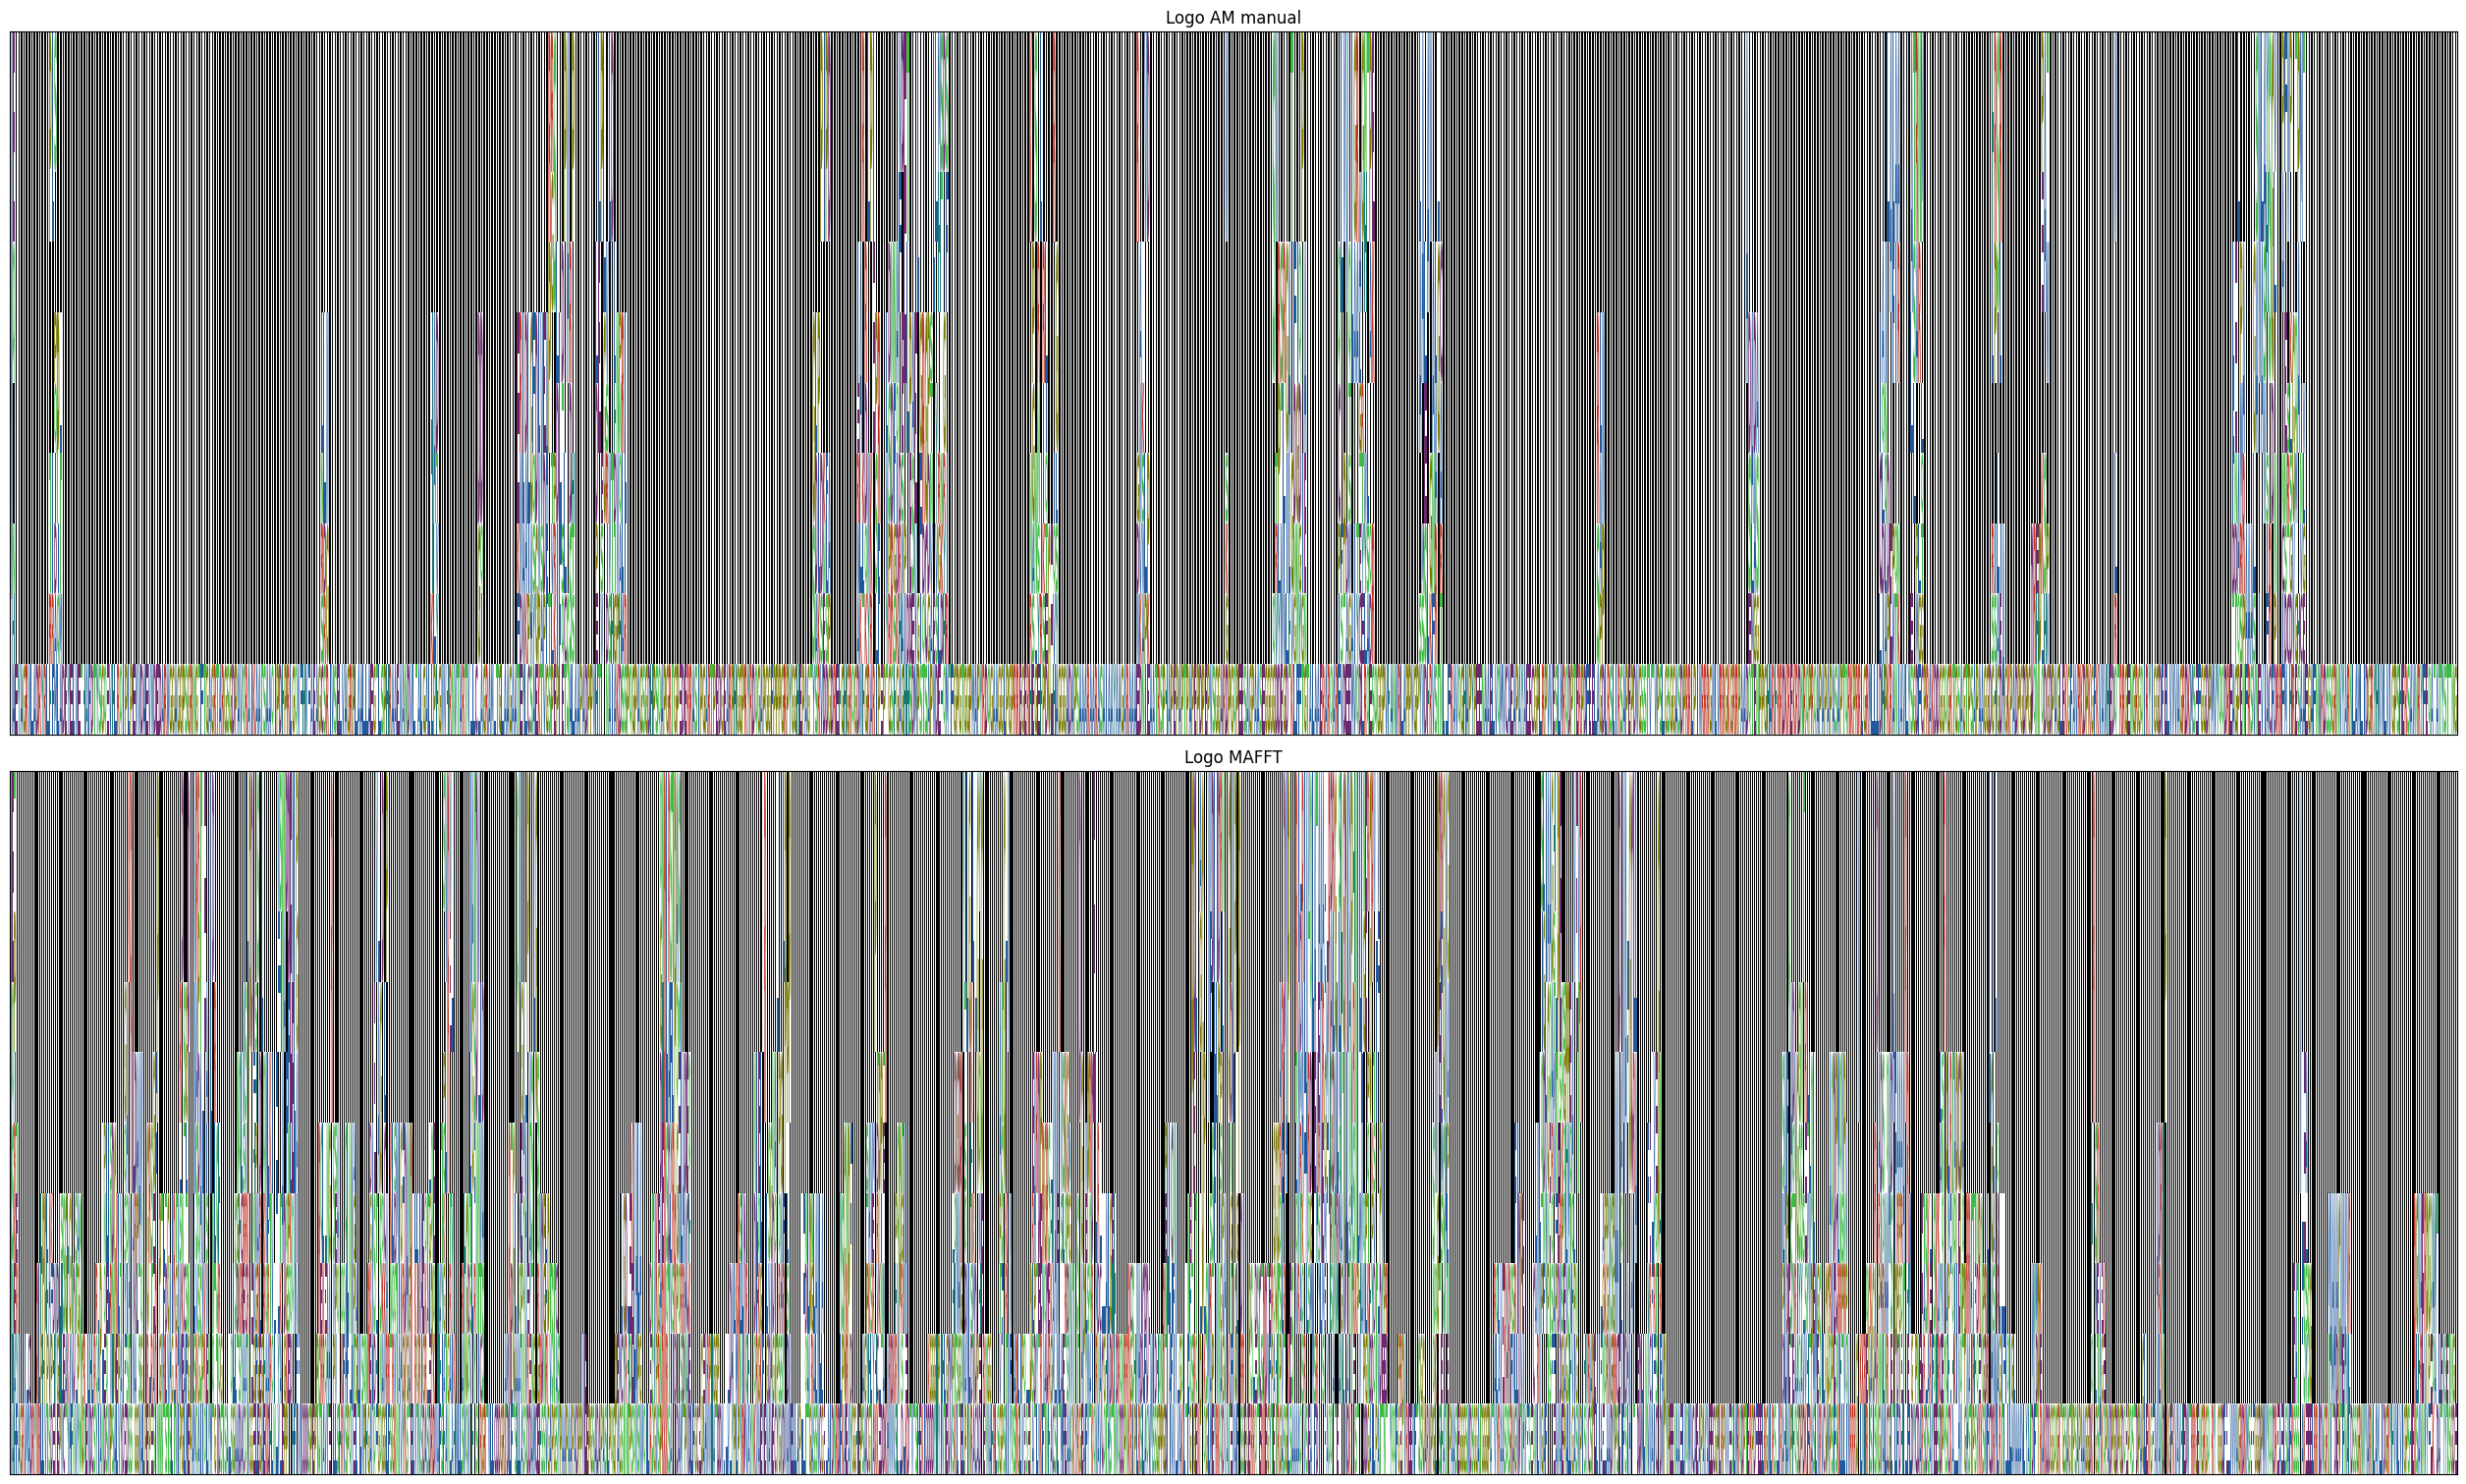

In [ ]:
import matplotlib.pyplot as plt
import logomaker

# Suponiendo que ya tenés:
# df_am_freq  -> DataFrame de frecuencias para tu AM
# df_mafft_freq -> DataFrame de frecuencias para MAFFT

# Crear figura con dos subplots (uno arriba del otro)
fig, axes = plt.subplots(2, 1, figsize=(25,15), constrained_layout=True)

# Logo AM manual
logomaker.Logo(df_am_freq, ax=axes[0], color_scheme='NajafabadiEtAl2017')
axes[0].set_title("Logo AM manual")
axes[0].set_xticks([])
axes[0].set_yticks([])

# Logo MAFFT
logomaker.Logo(df_mafft_freq, ax=axes[1], color_scheme='NajafabadiEtAl2017')
axes[1].set_title("Logo MAFFT")
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.show()


Claramente se ve la diferencia entre logos (para nada)

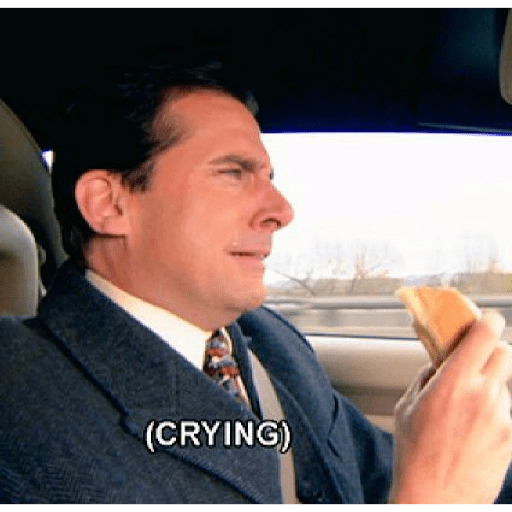